In [12]:
import pandas as pd
import numpy as np
import gc
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
# ==============================================================================
# 1. LOAD AND MERGE REQUIRED DATA
# ==============================================================================
print("Loading VAE outputs...")
vae_files = {
    'NP': ['TAS', 'hfls', 'zg', 'SIC'],
    'BK': ['TAS', 'hfls', 'zg', 'SIC'],
    'NAO': ['TAS', 'hfls', 'zg'] 
}

master_df = None
for region, variables in vae_files.items():
    for var in variables:
        filename = f"Data/{region}_{var}_full_latent_vaeb.csv"
        try:
            df = pd.read_csv(filename)
            df['time'] = pd.to_datetime(df['time'])
            
            float_cols = df.select_dtypes(include=['float64']).columns
            df[float_cols] = df[float_cols].astype('float32')
            df = df.drop_duplicates(subset=['member', 'time'])
            
            rename_map = {col: col.replace('latent_', f'latent_{region}_{var.upper()}_') 
                          for col in df.columns if col.startswith('latent_')}
            df = df.rename(columns=rename_map)
            
            if master_df is None:
                master_df = df
            else:
                master_df = pd.merge(master_df, df, on=['member', 'time'], how='left', validate='1:1')
        except FileNotFoundError:
            pass 

master_df['month'] = master_df['time'].dt.month

print("Loading filtering dependencies...")
bk_sic_df = pd.read_csv('Data/BK_SIC.csv')
bk_sic_df['time'] = pd.to_datetime(bk_sic_df['time'])
bk_sic_df = bk_sic_df.drop_duplicates(subset=['member', 'time'])

print("Loading Europe Temperature...")
ds_t = pd.read_csv('Data/europe_temp.csv')
ds_t['time'] = pd.to_datetime(ds_t['time'])
ds_t = ds_t.drop_duplicates(subset=['member', 'time'])
print("Loading and processing Europe Temperature...")
ds_t = pd.read_csv('Data/europe_temp.csv')
ds_t['time'] = pd.to_datetime(ds_t['time'])
ds_t = ds_t.drop_duplicates(subset=['member', 'time'])

ds_xr = ds_t.set_index(['time', 'member']).to_xarray()

def calc_historical_zscore(month_data, window=20):
    past_data = month_data.shift(time=1)
    rolled = past_data.rolling(time=window).construct("window_dim")
    baseline_mean = rolled.mean(dim=["member", "window_dim"], skipna=True)
    baseline_std = rolled.std(dim=["member", "window_dim"], skipna=True)
    return (month_data - baseline_mean) / baseline_std

eu_zscores = (
    ds_xr['europe_temp'].groupby("time.month")
    .map(calc_historical_zscore)
    .sortby("time")
)

zscore_df = eu_zscores.to_dataframe(name='eu_zscore').reset_index()

ds_t = pd.merge(ds_t, zscore_df, on=['time', 'member'], how='left')

npl_sic_df = pd.read_csv('Data/NPL_SIC.csv')
npl_sic_df['time'] = pd.to_datetime(npl_sic_df['time'])
npl_sic_df = npl_sic_df.drop_duplicates(subset=['member', 'time'])

master_df = pd.merge(master_df, npl_sic_df[['time', 'member', 'NPL_SIC']], on=['member', 'time'], how='left')
master_df = pd.merge(master_df, ds_t[['member', 'time', 'europe_temp', 'eu_zscore']], on=['member', 'time'], how='left', validate='1:1')
master_df = pd.merge(master_df, bk_sic_df[['time', 'member', 'BK_SIC']], on=['member', 'time'], how='left', validate='1:1')

# ==============================================================================
# 2. FILTER & EXTRACT SPECIFIC FEATURES
# ==============================================================================
print("Filtering dataset...")
valid_months = [10, 11, 12, 1, 2, 3]
mask = master_df['time'].dt.month.isin(valid_months) & (master_df['BK_SIC'] > 1)
master_df = master_df[mask].copy()

print(f"Master DataFrame rows after filtering: {len(master_df)}")

all_latent_cols = [col for col in master_df.columns if col.startswith('latent_')]
features_bk = [col for col in all_latent_cols if '_BK_' in col]
features_np = [col for col in all_latent_cols if '_NP_' in col]
features_nao = [col for col in all_latent_cols if '_NAO_' in col] 

tsne_features = features_bk + features_np + features_nao
# tsne_features = features_bk + features_np 

float_cols = master_df.select_dtypes(include=['float64']).columns
master_df[float_cols] = master_df[float_cols].astype('float32')
del bk_sic_df
gc.collect()

Loading VAE outputs...
Loading filtering dependencies...
Loading Europe Temperature...
Loading and processing Europe Temperature...


C:\Users\Jonas\miniconda3\envs\mlenv\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Jonas\miniconda3\envs\mlenv\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Jonas\miniconda3\envs\mlenv\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Jonas\miniconda3\envs\mlenv\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Jonas\miniconda3\envs\mlenv\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Filtering dataset...
Master DataFrame rows after filtering: 34934


54

Explained variance by 390 PCA components: 0.9995
--- DISTANCE BASELINES ---
10-NN: 20.95 ±  4.06
--------------------------
[r106 ] Z:  0.49 | Dist 10-NN: 24.43
[r139 ] Z:  0.11 | Dist 10-NN: 25.72
[r117 ] Z:  0.14 | Dist 10-NN: 26.51



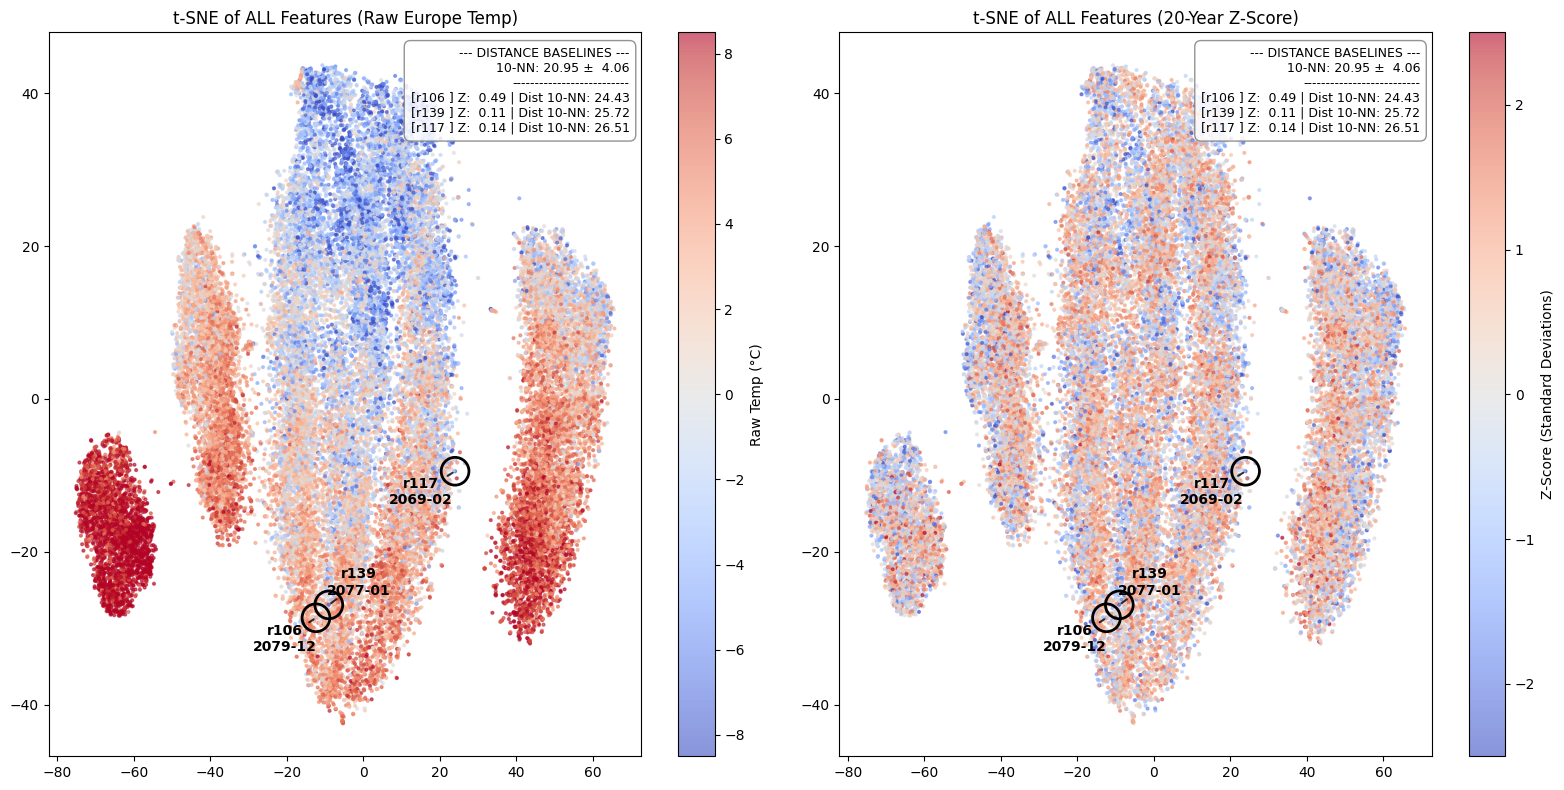

In [14]:
target_name = "ALL_seasonal"

master_df['month_sin'] = np.sin(2 * np.pi * master_df['month'] / 12.0)
master_df['month_cos'] = np.cos(2 * np.pi * master_df['month'] / 12.0)

target_features = tsne_features + ['month_sin', 'month_cos']

target_name = "ALL"

scaler = StandardScaler()
X_scaled = scaler.fit_transform(master_df[target_features])

seasonal_weight = 7.0 
X_scaled[:, -2:] *= seasonal_weight

if target_name == "NP":
    n_pca_dims = 160    
elif target_name == "BK":
    n_pca_dims = 64     
elif target_name == "ALL":
    n_pca_dims = 390    
else:
    raise ValueError(f"Give either target_name = 'BK', 'NP', or 'ALL'. Currently: {target_name}")
    
pca = PCA(n_components=min(n_pca_dims, len(target_features)))
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance by {pca.n_components} PCA components: {pca.explained_variance_ratio_.sum():.4f}")

tsne = TSNE(
    n_components=2, 
    perplexity=128,       
    init='pca',         
    learning_rate='auto', 
    random_state=42,
    n_jobs=-1            
)

tsne_results = tsne.fit_transform(X_pca)

plot_df = master_df[['time', 'member', 'month', 'europe_temp', 'eu_zscore']].copy()
plot_df['tsne_1'] = tsne_results[:, 0]
plot_df['tsne_2'] = tsne_results[:, 1]

plot_df = plot_df.dropna(subset=['europe_temp', 'eu_zscore'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

scatter_raw = axes[0].scatter(
    plot_df['tsne_1'], plot_df['tsne_2'],
    c=plot_df['europe_temp'], 
    cmap='coolwarm', 
    vmin=-8.5, vmax=8.5,
    s=4,          
    alpha=0.6     
)
plt.colorbar(scatter_raw, ax=axes[0], label='Raw Temp (°C)')
axes[0].set_title(f't-SNE of {target_name} Features (Raw Europe Temp)')

scatter_z = axes[1].scatter(
    plot_df['tsne_1'], plot_df['tsne_2'],
    c=plot_df['eu_zscore'], 
    cmap='coolwarm', 
    vmin=-2.5, vmax=2.5, 
    s=4,
    alpha=0.6
)
plt.colorbar(scatter_z, ax=axes[1], label='Z-Score (Standard Deviations)')
axes[1].set_title(f't-SNE of {target_name} Features (20-Year Z-Score)')

model_names = ["r106", "r139", "r117"]
time_stamp = ["2079-12-16T12:00:00", "2077-01-16T12:00:00", "2069-02-15"]
time_stamp_read = ["2079-12", "2077-01", "2069-02"]

nn_true = NearestNeighbors(n_neighbors=11)
nn_true.fit(X_pca) 

all_distances, _ = nn_true.kneighbors(X_pca)

global_avg_1nn = all_distances[:, 1].mean()
global_avg_1nn_std = all_distances[:, 1].std()

global_avg_10nn = all_distances[:, 1:].mean()
global_avg_10nn_std = all_distances[:, 1:].std()

info_text = (
    f"--- DISTANCE BASELINES ---\n"
    # f"1-NN : {global_avg_1nn:>5.2f} ± {global_avg_1nn_std:>5.2f}\n"
    f"10-NN: {global_avg_10nn:>5.2f} ± {global_avg_10nn_std:>5.2f}\n"
    f"--------------------------\n"
)

model_names = ["r106", "r139", "r117"]
time_stamp = ["2079-12-16T12:00:00", "2077-01-16T12:00:00", "2069-02-15"]
time_stamp_read = ["2079-12", "2077-01", "2069-02"]

points_to_plot = []
for m, t, t_read in zip(model_names, time_stamp, time_stamp_read):
    t_dt = pd.to_datetime(t)
    mask = (plot_df['member'] == m) & (plot_df['time'] == t_dt)
    
    if mask.any():
        row_idx = np.where(mask)[0][0]
        tsne_x = plot_df.loc[mask, 'tsne_1'].values[0]
        tsne_y = plot_df.loc[mask, 'tsne_2'].values[0]
        
        true_latent_vector = X_pca[row_idx].reshape(1, -1)
        distances, indices = nn_true.kneighbors(true_latent_vector)
        
        neighbor_indices = indices[0][1:] 
        neighbor_distances = distances[0][1:] 
        
        avg_zscore = plot_df.iloc[neighbor_indices]['eu_zscore'].mean()
        avg_dist = neighbor_distances.mean()
        
        info_text += f"[{m:<4} ] Z: {avg_zscore:>5.2f} | Dist 10-NN: {avg_dist:>5.2f}\n"

        points_to_plot.append((tsne_x, tsne_y, m, t_read))

print(info_text)

for ax in axes:
    texts, pt_x, pt_y = [], [], []
    
    for tsne_x, tsne_y, m, t_read in points_to_plot:
        ax.scatter(tsne_x, tsne_y, facecolors='none', edgecolors='black', 
                   s=400, linewidths=2, zorder=10)
        
        txt = ax.text(tsne_x, tsne_y, f"{m}\n{t_read}", 
                      ha='center', va='center', color='black', fontweight='bold', zorder=11)
        
        texts.append(txt)
        pt_x.append(tsne_x)
        pt_y.append(tsne_y)
        
    if texts:
        adjust_text(texts, x=pt_x, y=pt_y, ax=ax, 
                    arrowprops=dict(arrowstyle='-', color='black', lw=1.5, alpha=0.8))
    
    ax.text(0.98, 0.98, info_text.strip(), transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', horizontalalignment='right', 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='gray'),
            zorder=15)

plt.tight_layout()
plt.savefig(f'Saved_Plots/tsne_{target_name}_temp_comparison.png', dpi=300)
plt.show()

Extracting variables for correlation matrix...
Calculating correlation matrix for 627 dimensions...


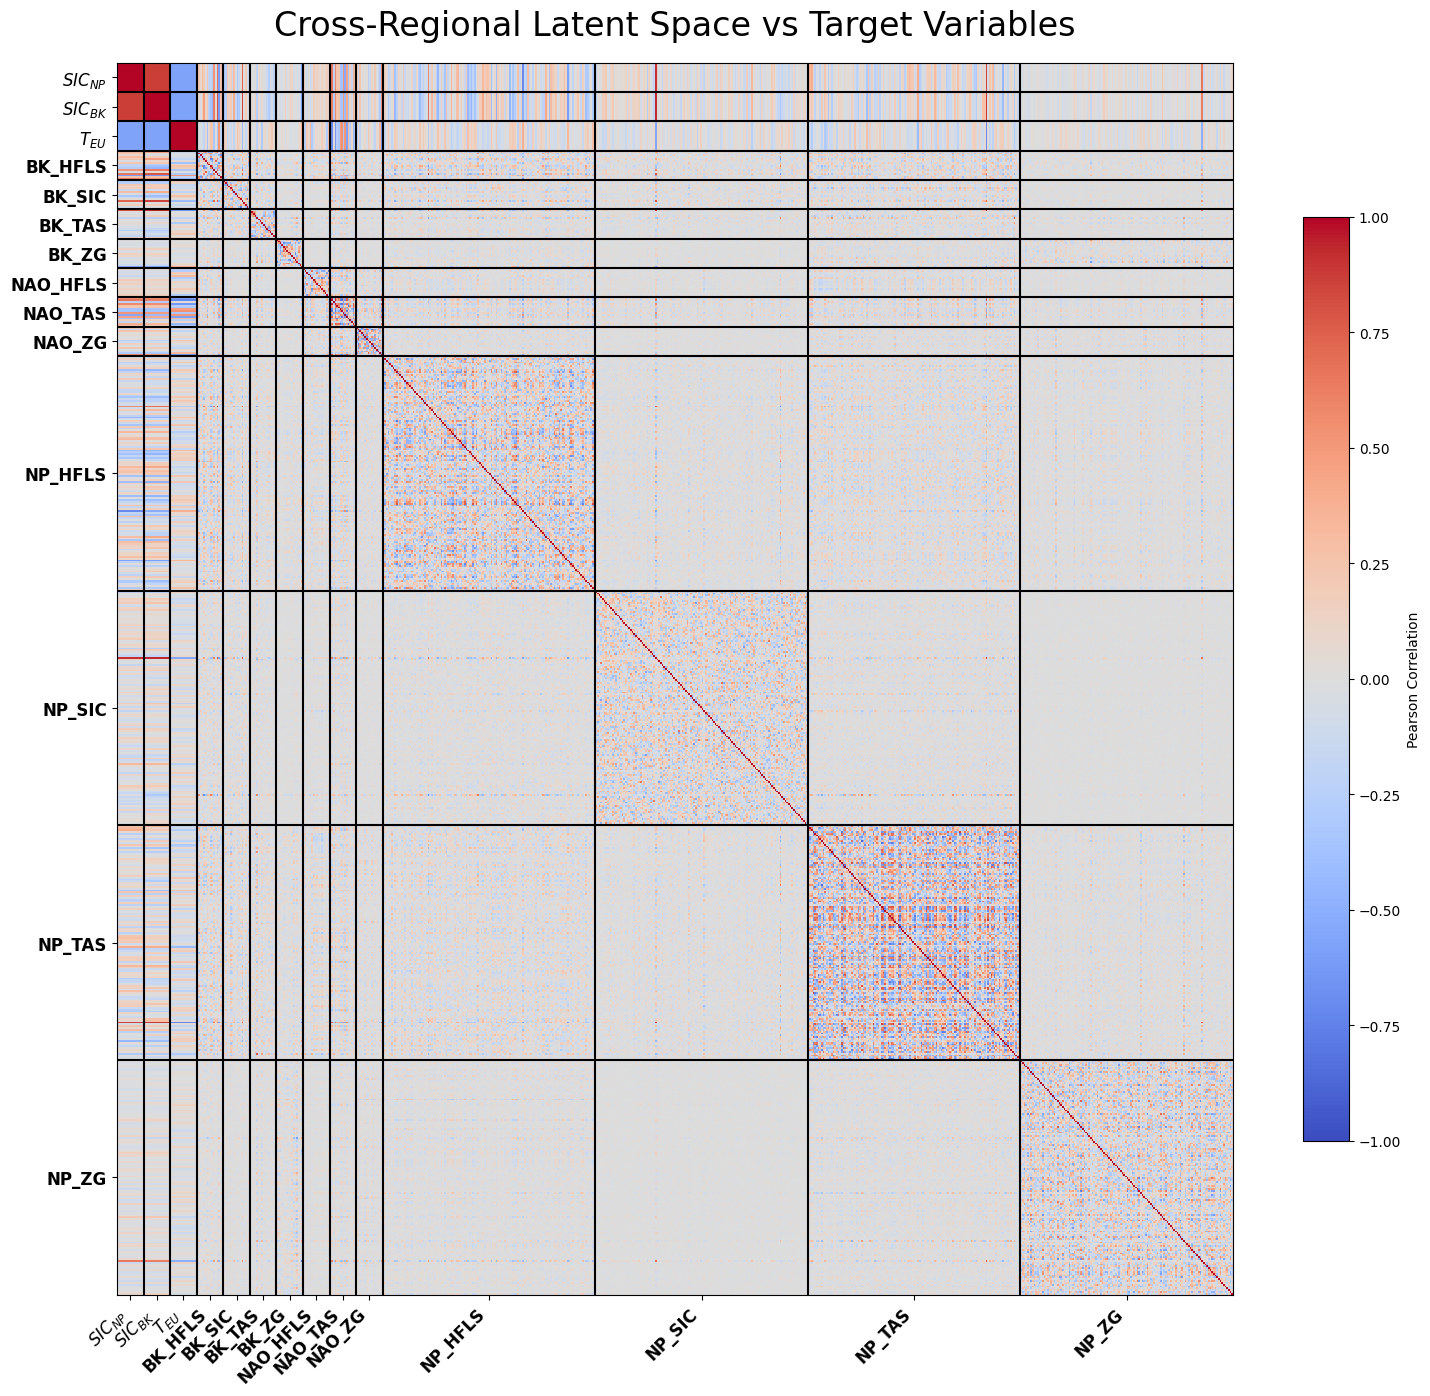

Stretched correlation matrix saved to Saved_Plots/correlation_matrix_NP.png


In [5]:
print("Extracting variables for correlation matrix...")

include_np = True 

# 1. Map Targets based on configuration
if include_np:
    target_mapping = {
        'NPL_SIC': r'$SIC_{NP}$',
        'BK_SIC': r'$SIC_{BK}$',
        'europe_temp': r'$T_{EU}$'
    }
    output_image = 'Saved_Plots/correlation_matrix_NP.png'
else:
    target_mapping = {
        'BK_SIC': r'$SIC_{BK}$',
        'europe_temp': r'$T_{EU}$'
    }
    output_image = 'Saved_Plots/correlation_matrix_BK.png'

# Only grab targets that currently exist in master_df
available_targets = [col for col in target_mapping.keys() if col in master_df.columns]
targets_df = master_df[available_targets].rename(columns=target_mapping)

# 2. Extract and format the Latent variables
latent_cols = [col for col in master_df.columns if col.startswith('latent_')]

# Aggressively drop NP latent spaces if the toggle is False
if not include_np:
    latent_cols = [col for col in latent_cols if not col.startswith('latent_NP_')]

latent_df = master_df[latent_cols].copy()

# Remove 'latent_' prefix so your grouping logic works perfectly
latent_df = latent_df.rename(columns=lambda x: x.replace('latent_', ''))

# Sort alphabetically to group them by Region and Variable
latent_df = latent_df[sorted(latent_df.columns)]

# 3. Final Merge & Correlation
combined_df = pd.concat([targets_df, latent_df], axis=1)
all_cols = combined_df.columns

print(f"Calculating correlation matrix for {combined_df.shape[1]} dimensions...")
corr_matrix = combined_df.corr().values 

# 4. Stretch Logic
widths = []
stretch_factor = 16  

for col in all_cols:
    if col in targets_df.columns:
        widths.append(stretch_factor)
    else:
        widths.append(1)

edges = np.insert(np.cumsum(widths), 0, 0)

# 5. Dynamically map the scaled centers and boundaries
var_centers = {}
var_boundaries = []
current_group = None
start_edge = 0

for i, col in enumerate(all_cols):
    if col in targets_df.columns:
        group_name = col 
    else:
        parts = col.split('_')
        group_name = f"{parts[0]}_{parts[1]}" if len(parts) >= 2 else "Unknown"
    
    if current_group is None:
        current_group = group_name
        start_edge = edges[i]
    elif current_group != group_name:
        var_centers[current_group] = start_edge + (edges[i] - start_edge) / 2
        var_boundaries.append(edges[i])
        current_group = group_name
        start_edge = edges[i]

var_centers[current_group] = start_edge + (edges[-1] - start_edge) / 2

# 6. Draw the Stretched Matrix
fig, ax = plt.subplots(figsize=(18, 16))
X, Y = np.meshgrid(edges, edges)

c = ax.pcolormesh(X, Y, corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.invert_yaxis()

fig.colorbar(c, ax=ax, shrink=0.75, label="Pearson Correlation")

# 7. Apply custom scaled labels
ax.set_xticks(list(var_centers.values()))
ax.set_xticklabels(list(var_centers.keys()), fontsize=12, fontweight='bold', rotation=45, ha='right')

ax.set_yticks(list(var_centers.values()))
ax.set_yticklabels(list(var_centers.keys()), fontsize=12, fontweight='bold', rotation=0)

# 8. Draw crisp divider lines
for boundary in var_boundaries:
    ax.axvline(boundary, color='black', linewidth=1.5)
    ax.axhline(boundary, color='black', linewidth=1.5)

plt.title(f"Cross-Regional Latent Space vs Target Variables", fontsize=24, pad=20)

plt.savefig(output_image, dpi=100, bbox_inches='tight')
plt.show()

print(f"Stretched correlation matrix saved to {output_image}")